# **Assignment 13**

# Data preparation process

The data preparation starts with the raw exercise videos. Each video is processed with MediaPipe Pose Landmarker to extract body landmarks for every frame. For each frame, we keep 13 selected joints, and each joint has an x, y, and z coordinate. This gives 39 features per frame.

After extracting the landmarks, the videos are still uncut, meaning they may contain frames before and after the actual squat. To remove these irrelevant parts, we use the running model from the previous assignment. This model predicts which frames belong to the movement. The video is then trimmed to only contain the exercise sequence.

Each trimmed video becomes one data point. Since different videos have different numbers of frames, we first find the longest trimmed sequence in the dataset. This length is used as the common sequence length. All shorter videos are padded with trailing zero frames so that every video has the same shape. In our case, the longest video has 173 frames, so every video is converted to the shape (173, 39).

The target value is assigned from the filename. Videos that represent a good squat are labeled as 1, while videos that represent a bad squat are labeled as 0. This means that the whole sequence gets one label, not each individual frame.

Finally, each padded sequence is flattened and saved as a CSV file. Even though the CSV stores the values as one long row, it still represents a sequence of frames. When loading the data for training, the row can be reshaped back into (number_of_frames, 39). This gives the model one full movement sequence as input and one good/bad label as output.


Some videos were manually removed after the trimming step because the start/stop model did not correctly identify the squat sequence. In certain cases, the model included too many irrelevant frames or removed important parts of the movement, which resulted in poor quality sequences. Since these incorrectly trimmed videos could negatively affect the training process, they were excluded from the final dataset.

In future work, a function should be implemented to automatically detect poorly trimmed videos and classify them as invalid samples. This would remove the need for manual inspection and make the preprocessing pipeline more robust and fully automated. Such a function could, for example, identify sequences that are too short, contain fragmented movement predictions, or include unrealistic frame transitions.

**Removed  Videos**
- W01
- W02
- W03
- W04
- W13
- W14
- W19
- W20
- W27
- W29
- W37

## Imports

In [4]:
import os
import re
import numpy as np
import torch
import torch.nn as nn
import pandas as pd
import cv2
import mediapipe as mp
import numpy as np
from mediapipe.tasks import python
from mediapipe.tasks.python import vision
import joblib
import matplotlib.pyplot as plt
from IPython.display import HTML
import random
import torch.nn.functional as F
import torch.optim as optim
from sklearn.preprocessing import StandardScaler
from torchinfo import summary
from datetime import datetime
import json
from sklearn.metrics import (
    confusion_matrix,
    ConfusionMatrixDisplay,
    accuracy_score,
    precision_score,
    recall_score,
    roc_auc_score,
    f1_score
)



if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")

random_seed = 42

## Functions for preprocessing (video -> mediapipe -> cut csv -> equally long padded squat sequences)

In [67]:
def extract_mediapipe_to_csv(data_path: str, save_path: str, model_path: str):

    video_extensions = [".mp4", ".mov", ".avi", ".mkv"]
    static = not any(data_path.lower().endswith(ext) for ext in video_extensions)

    base_options = python.BaseOptions(model_asset_path=model_path)

    JOINT_ORDER = [
        "head",
        "left_shoulder", "left_elbow",
        "right_shoulder", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot"
    ]

    LANDMARK_INDEX = {
        "head": 0,  
        "left_shoulder": 11,
        "right_shoulder": 12,
        "left_elbow": 13,
        "right_elbow": 14,
        "left_hand": 15,
        "right_hand": 16,
        "left_hip": 23,
        "right_hip": 24,
        "left_knee": 25,
        "right_knee": 26,
        "left_foot": 27,
        "right_foot": 28,
    }

    data = []

    if static:
        options = vision.PoseLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.IMAGE,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5
        )

        with vision.PoseLandmarker.create_from_options(options) as landmarker:
            image = cv2.imread(data_path)
            if image is None:
                raise ValueError(f"Could not read image: {data_path}")

            image_rgb = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
            mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)
            results = landmarker.detect(mp_image)

            if results.pose_landmarks:
                row = {"FrameNo": 0}

                for joint in JOINT_ORDER:
                    idx = LANDMARK_INDEX[joint]
                    lm = results.pose_landmarks[0][idx]

                    row[f"{joint}_x"] = lm.x
                    row[f"{joint}_y"] = lm.y
                    row[f"{joint}_z"] = lm.z

                data.append(row)

    else:
        options = vision.PoseLandmarkerOptions(
            base_options=base_options,
            running_mode=vision.RunningMode.VIDEO,
            min_pose_detection_confidence=0.5,
            min_pose_presence_confidence=0.5,
            min_tracking_confidence=0.5
        )

        with vision.PoseLandmarker.create_from_options(options) as landmarker:
            cap = cv2.VideoCapture(data_path)

            if not cap.isOpened():
                raise ValueError(f"Could not open video: {data_path}")

            fps = cap.get(cv2.CAP_PROP_FPS)
            frame_idx = 0

            while cap.isOpened():
                ret, frame = cap.read()
                if not ret:
                    break

                image_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
                mp_image = mp.Image(image_format=mp.ImageFormat.SRGB, data=image_rgb)

                timestamp_ms = int((frame_idx / fps) * 1000)
                results = landmarker.detect_for_video(mp_image, timestamp_ms)

                if results.pose_landmarks:
                    row = {"FrameNo": frame_idx}

                    for joint in JOINT_ORDER:
                        idx = LANDMARK_INDEX[joint]
                        lm = results.pose_landmarks[0][idx]

                        row[f"{joint}_x"] = lm.x
                        row[f"{joint}_y"] = lm.y
                        row[f"{joint}_z"] = lm.z

                    data.append(row)

                frame_idx += 1

            cap.release()

    # ---- SAVE CSV ----
    columns = ["FrameNo"]
    for joint in JOINT_ORDER:
        columns += [f"{joint}_x", f"{joint}_y", f"{joint}_z"]

    df = pd.DataFrame(data)
    df = df[columns]

    #os.makedirs(os.path.dirname(save_path), exist_ok=True)
    #df.to_csv(save_path, index=False)
    #print(f"Saved {len(df)} rows to {save_path}")

    return df



class Recurrent_classifier(nn.Module):
    def __init__(self, hidden_layers: list, layer_type="LSTM", dropout=0):
        super().__init__()

        input_size = 39
        rnn_class  = nn.LSTM if layer_type == "LSTM" else nn.GRU

        self.rnns  = nn.ModuleList()
        self.drops = nn.ModuleList()
        self.norms = nn.ModuleList()  # Add normalization layers

        sizes = [input_size] + hidden_layers
        for i in range(len(hidden_layers)):
            in_size = sizes[i] * 2 if i > 0 else sizes[i]  # *2 because bidirectional doubles output
            self.rnns.append(rnn_class(in_size, sizes[i + 1], batch_first=True, bidirectional=True))
            self.drops.append(nn.Dropout(dropout) if dropout > 0 else nn.Identity())
            
            # Add LayerNorm after each RNN (normalize over the hidden dimension)
            hidden_dim = sizes[i + 1] * 2  # *2 for bidirectional
            self.norms.append(nn.LayerNorm(hidden_dim))

        self.fc_out = nn.Linear(hidden_layers[-1] * 2, 1)  # *2 for bidirectional

    def forward(self, x):
        for rnn, drop, norm in zip(self.rnns, self.drops, self.norms):
            x, _ = rnn(x)
            x = norm(x)  # Apply layer normalization
            x = drop(x)
    
        return self.fc_out(x)  # (batch, seq_len, 1) — raw logits


def trim_csv_with_rnn_model(model, df, scaler, seq_length=30, stride=15, threshold=0.5):
    df = df.copy()
    df.columns = df.columns.str.strip()

    if "FrameNo" not in df.columns:
        df["FrameNo"] = np.arange(len(df))

    feature_cols = [c for c in df.columns
        if c.endswith("_x") or c.endswith("_y") or c.endswith("_z")]

    X_np = df[feature_cols].values.astype(np.float32)
    X_scaled = scaler.transform(X_np)

    probs_sum = np.zeros(len(df))
    counts = np.zeros(len(df))

    model.eval()
    with torch.no_grad():
        for i in range(0, len(df) - seq_length + 1, stride):
            seq = X_scaled[i:i + seq_length]

            X = torch.tensor(seq, dtype=torch.float32).unsqueeze(0).to(device)
            logits = model(X)

            probs = torch.sigmoid(logits).cpu().numpy().flatten()

            probs_sum[i:i + seq_length] += probs
            counts[i:i + seq_length] += 1

    frame_probs = probs_sum / np.maximum(counts, 1)
    preds = (frame_probs >= threshold).astype(int)

    print("Predictions:")
    print(preds)

    df["pred_running"] = preds

    movement_frames = df[df["pred_running"] == 1]

    if len(movement_frames) == 0:
        print("No movement detected")
        return None

    start_idx = movement_frames.index.min()
    stop_idx = movement_frames.index.max()

    trimmed_df = df.loc[start_idx:stop_idx].drop(columns=["pred_running"])

    print(f"Start index: {start_idx}, Stop index: {stop_idx}")

    return trimmed_df


def get_quality_label(file_name):

    base = os.path.basename(file_name)

    if base.startswith("A") or base.startswith("G"):
        return 1
    elif base.startswith("W"):
        return 0
    else:
        raise ValueError(f"Unknown label for file: {file_name}")


def get_feature_columns(df):
    joints = [
        "head",
        "left_shoulder", "left_elbow",
        "right_shoulder", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot"
    ]

    feature_cols = []
    for joint in joints:
        feature_cols += [f"{joint}_x", f"{joint}_y", f"{joint}_z"]

    return feature_cols


def pad_sequence(df, max_frames):
    feature_cols = get_feature_columns(df)

    X = df[feature_cols].values.astype(np.float32)

    n_frames = len(X)
    n_features = X.shape[1]

    padded_X = np.zeros((max_frames, n_features), dtype=np.float32)
    padded_X[:n_frames] = X

    return padded_X


def build_padded_video_dataset(
    video_folder,
    output_folder,
    mediapipe_model_path,
    start_stop_model,
    start_stop_scaler,
    seq_length=30,
    stride=10,
    threshold=0.5
):
    """
    Full pipeline:

    1. Run MediaPipe on every video
    2. Trim each video using start/stop model
    3. Get target from filename
    4. Find longest trimmed sequence
    5. Pad all shorter sequences with zeros
    6. Save one CSV per video with readable feature names
    """

    os.makedirs(output_folder, exist_ok=True)

    video_extensions = [".mp4", ".mov", ".avi", ".mkv"]

    joints = [
        "head",
        "left_shoulder", "left_elbow",
        "right_shoulder", "right_elbow",
        "left_hand", "right_hand",
        "left_hip", "right_hip",
        "left_knee", "right_knee",
        "left_foot", "right_foot"
    ]

    processed_videos = []

    # =====================================================
    # FIRST PASS: extract + trim + store in memory
    # =====================================================

    for file_name in os.listdir(video_folder):

        if not any(file_name.lower().endswith(ext) for ext in video_extensions):
            continue

        print(f"\nProcessing: {file_name}")

        video_path = os.path.join(video_folder, file_name)

        # 1. Run MediaPipe
        df_mediapipe = extract_mediapipe_to_csv(
            data_path=video_path,
            save_path="",
            model_path=mediapipe_model_path
        )

        if df_mediapipe is None or len(df_mediapipe) == 0:
            print(f"Skipping {file_name}: no MediaPipe landmarks found")
            continue

        # 2. Trim with start/stop model
        trimmed_df = trim_csv_with_rnn_model(
            model=start_stop_model,
            df=df_mediapipe,
            scaler=start_stop_scaler,
            seq_length=seq_length,
            stride=stride,
            threshold=threshold
        )

        if trimmed_df is None or len(trimmed_df) == 0:
            print(f"Skipping {file_name}: no movement detected")
            continue

        # 3. Get label
        target = get_quality_label(file_name)

        processed_videos.append({
            "file_name": file_name,
            "trimmed_df": trimmed_df,
            "target": target,
            "length": len(trimmed_df)
        })

        print(f"Trimmed length: {len(trimmed_df)} frames")
        print(f"Target: {target}")

    if len(processed_videos) == 0:
        raise ValueError("No videos were successfully processed.")

    # =====================================================
    # FIND LONGEST SEQUENCE
    # =====================================================

    max_frames = max(video["length"] for video in processed_videos)

    print("\nLongest trimmed sequence:")
    print(f"{max_frames} frames")

    # =====================================================
    # CREATE READABLE COLUMN NAMES
    # =====================================================

    columns = []

    for frame_idx in range(max_frames):
        for joint in joints:
            columns += [
                f"frame{frame_idx}_{joint}_x",
                f"frame{frame_idx}_{joint}_y",
                f"frame{frame_idx}_{joint}_z"
            ]

    columns.append("target")

    # =====================================================
    # SECOND PASS: pad + save one CSV per video
    # =====================================================

    for video in processed_videos:

        file_name = video["file_name"]
        trimmed_df = video["trimmed_df"]
        target = video["target"]

        padded_X = pad_sequence(trimmed_df, max_frames=max_frames)

        row = padded_X.flatten().tolist()
        row.append(target)

        output_df = pd.DataFrame([row], columns=columns)

        base_name = os.path.splitext(file_name)[0]
        output_path = os.path.join(output_folder, f"{base_name}_padded.csv")

        # --- UNCOMMENT TO SAVE THE CSV FILES ---
        output_df.to_csv(output_path, index=False)

        print(f"Saved: {output_path}")

    print("\nDone.")
    print(f"Saved {len(processed_videos)} padded video CSV files.")
    print(f"Each video padded to {max_frames} frames.")

## Paths to the cutting model + the saving folder for preprocessed csv data

In [68]:
model_path = "trim_model.pt"
scaler_path = "trim_scaler.joblib"

# --- INSERT PATH TO THE VIDEOS YOU WANT TO USE HERE ---
video_folder_path = "../../../GoodvsBad"


output_folder = "mediapipe_padded_videos"

## Load model and belonging scaler

In [69]:
checkpoint = torch.load(model_path, map_location=device)

config = checkpoint["hyperparameters"]

model = Recurrent_classifier(
    hidden_layers=config["hidden_layers"],
    layer_type=config.get("layer_type", "LSTM"),
    dropout=config["dropout"]
).to(device)

model.load_state_dict(checkpoint["model_state_dict"])
model.eval()

scaler = joblib.load(scaler_path)


## Build cut and padded csv files from the videos

In [70]:
build_padded_video_dataset(
    video_folder=video_folder_path,
    output_folder=output_folder,
    mediapipe_model_path="pose_landmarker.task",
    start_stop_model=model,
    start_stop_scaler=scaler,
    seq_length=config["seq_length"],
    stride=config["stride"],
    threshold=0.5
)


Processing: W28.avi


I0000 00:00:1778713166.387176 1316505 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1778713166.467883 1316507 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778713166.495859 1316509 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Start index: 25, Stop index: 85
Trimmed length: 61 frames
Target: 0

Processing: G43.avi


I0000 00:00:1778713169.843804 1316568 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1778713169.906524 1316571 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778713169.916825 1316571 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Start index: 60, Stop index: 109
Trimmed length: 50 frames
Target: 1

Processing: G57.avi


...

Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 1 1 1 1 1 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0]
Start index: 41, Stop index: 151
Trimmed length: 111 frames
Target: 0

Processing: W31.avi


I0000 00:00:1778713622.466831 1322801 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1778713622.528065 1322805 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778713622.537893 1322809 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
Start index: 93, Stop index: 159
Trimmed length: 67 frames
Target: 0

Processing: G66.avi


I0000 00:00:1778713627.313623 1322837 gl_context.cc:407] GL version: 2.1 (2.1 Metal - 89.4), renderer: Apple M2
W0000 00:00:1778713627.376609 1322839 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.
W0000 00:00:1778713627.385524 1322840 inference_feedback_manager.cc:121] Feedback manager requires a model with a single signature inference. Disabling support for feedback tensors.


Predictions:
[0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1 1
 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
Start index: 40, Stop index: 113
Trimmed length: 74 frames
Target: 1

Longest trimmed sequence:
173 frames
Saved: mediapipe_padded_videos/W28_padded.csv
Saved: mediapipe_padded_videos/G43_padded.csv
Saved: mediapipe_padded_videos/G57_padded.csv
Saved: mediapipe_padded_videos/G80_padded.csv
Saved: mediapipe_padded_videos/G81_padded.csv
Saved: mediapipe_padded_videos/G56_padded.csv
Saved: mediapipe_padded_videos/G42_padded.csv
Saved: mediapipe_padded_videos/W15_padded.csv
Saved: mediapipe_padded_videos/G68_padded.csv
Saved: mediapipe_padded_videos/G54_padded.csv
Saved: mediapipe_

# **Data management**

## Functions for data management

In [5]:
def reshape_to_cnn_input(x, feature_columns):
    if hasattr(x, 'values'):
        x = x.values
    frame_numbers = sorted(set(int(re.search(r'frame(\d+)_', col).group(1)) for col in feature_columns))
    feature_names = sorted(set(re.sub(r'^frame\d+_', '', col) for col in feature_columns))
    n_samples = x.shape[0]
    n_frames = len(frame_numbers)
    n_features = len(feature_names)
    print(f"Reshaping: {n_samples} samples, {n_frames} frames, {n_features} features")
    col_index = {col: i for i, col in enumerate(feature_columns)}
    x_4d = np.zeros((n_samples, 1, n_frames, n_features))
    for f_idx, frame_num in enumerate(frame_numbers):
        for feat_idx, feat_name in enumerate(feature_names):
            col_name = f"frame{frame_num}_{feat_name}"
            if col_name in col_index:
                x_4d[:, 0, f_idx, feat_idx] = x[:, col_index[col_name]]
    return x_4d, (n_frames, n_features)

In [6]:
def load(files, data_dir):
    dataframes = []

    for f in files:
        path = os.path.join(data_dir, f)   
        df = pd.read_csv(path)

        # Get rid of trailing whitespace
        df.columns = df.columns.str.strip()           
        dataframes.append(df)             

    combined = pd.concat(dataframes, ignore_index=True)  # combine all

    return combined

def split_csvfiles(datafolder, random_seed, training_prop, validation_prop):
    csv_files = []
    for f in os.listdir(datafolder):
        if f.endswith(".csv"):
            csv_files.append(f)

    random.seed(random_seed)
    random.shuffle(csv_files)

    train_n = int(len(csv_files) * training_prop)
    val_n = int(len(csv_files) * validation_prop)

    # Split
    if validation_prop == 0:
        train_files = csv_files[:train_n]
        test_files = csv_files[train_n:]

        return train_files, test_files

    else:
        train_files = csv_files[:train_n]
        val_files = csv_files[train_n: train_n + val_n]
        test_files = csv_files[train_n + val_n:]

        return train_files, val_files, test_files

def select_joints(X, joints):
    selected_cols = []
    for col in X.columns:
        if any(joint in col for joint in joints):
            selected_cols.append(col)
    
    return X[selected_cols].copy()

# Function to only use every n'th frame
def select_every_nth_frame(df, step=3):
    selected_cols = []

    for col in df.columns:
        # Extract frame number
        frame_part = col.split("_")[0]
        frame_idx = int(frame_part.replace("frame", ""))

        if frame_idx % step == 0:
            selected_cols.append(col)

    return df[selected_cols].copy()

def angle(p1, p2, p3):
    v1 = p1 - p2
    v2 = p3 - p2

    norm_v1 = np.linalg.norm(v1)
    norm_v2 = np.linalg.norm(v2)

    # Handle degenerate cases
    if norm_v1 == 0 or norm_v2 == 0:
        return np.nan

    cos_angle = np.dot(v1, v2) / (norm_v1 * norm_v2)
    cos_angle = np.clip(cos_angle, -1.0, 1.0)

    return np.degrees(np.arccos(cos_angle))

def add_angle_features(df, frames=173):
    df = df.copy()

    # Store aggregated features per row (video)
    features = []

    for idx, row in df.iterrows():
        left_knee, right_knee = [], []
        left_hip, right_hip = [], []

        for f in range(frames):
            prefix = f"frame{f}"

            try:
                def get(joint):
                    return np.array([
                        row[f"{prefix}_{joint}_x"],
                        row[f"{prefix}_{joint}_y"],
                        row[f"{prefix}_{joint}_z"]
                    ])

                lk = angle(get("left_hip"), get("left_knee"), get("left_foot"))
                rk = angle(get("right_hip"), get("right_knee"), get("right_foot"))

                lh = angle(get("left_shoulder"), get("left_hip"), get("left_knee"))
                rh = angle(get("right_shoulder"), get("right_hip"), get("right_knee"))

                left_knee.append(lk)
                right_knee.append(rk)
                left_hip.append(lh)
                right_hip.append(rh)

            except:
                continue

        # Aggregate per video
        features.append({
            "lk_mean": np.mean(left_knee),
            "lk_min": np.min(left_knee),
            "lk_max": np.max(left_knee),

            "rk_mean": np.mean(right_knee),
            "rk_min": np.min(right_knee),
            "rk_max": np.max(right_knee),

            "lh_mean": np.mean(left_hip),
            "lh_min": np.min(left_hip),
            "lh_max": np.max(left_hip),

            "rh_mean": np.mean(right_hip),
            "rh_min": np.min(right_hip),
            "rh_max": np.max(right_hip),
        })

    feature_df = pd.DataFrame(features, index=df.index)

    return feature_df

# Modified Karl's augmentation function for training
def mirror_dataframe(df, mirror_x=True, mirror_y=True, mirror_z=True):
    """
    Mirror pose data by swapping left/right joints.

    Assumes column format: frameX_joint_coord
    """

    df_copy = df.copy()

    mirror_pairs = [
        ("left_shoulder", "right_shoulder"),
        ("left_elbow", "right_elbow"),
        ("left_hand", "right_hand"),
        ("left_hip", "right_hip"),
        ("left_knee", "right_knee"),
        ("left_foot", "right_foot"),
    ]

    for col in df.columns:
        parts = col.split("_")

        # Example: frame0_left_knee_x
        frame = parts[0]
        coord = parts[-1]
        joint = "_".join(parts[1:-1])

        for left, right in mirror_pairs:

            if joint == left:
                mirrored_col = f"{frame}_{right}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

            elif joint == right:
                mirrored_col = f"{frame}_{left}_{coord}"

                if mirrored_col in df.columns:
                    df_copy[col] = df[mirrored_col]

    return df_copy

## Data management

- Split data into training/test by files
- Load into dataframes
- Split input (frame#_joint_x, frame#_joint_y, frame#_joint_z) and target (1/0 good/bad)
- Extract data for the useful joints (shoulder, hips, knee, feet)
- Select every n'th frame (we use every 3rd)
- Apply feature engineering to get angle features
- Apply augmentation to get more samples

=> 144 samples (double what we had)

- Scale data
- Tensorize the data
- Dimensionalize data to 2D (for the CNN model)

In [ ]:
# --- UNCOMMENT TO LOAD THE PREPROCESSED VIDEOS FROM THE GENERATED FOLDER ---
data_folder = "mediapipe_padded_videos"


#data_folder = "../data/mediapipe_padded_videos"

# Split which files should be train, val and test - we use 70/30 train/test due to small amount of samples
training_proportion = 0.7
validation_proportion = 0

train_files, test_files = split_csvfiles(data_folder, random_seed, training_proportion, validation_proportion)

# Load df from files selected to be either training or testing
train_data = load(train_files, data_folder)
test_data = load(test_files, data_folder)

# Split
y_train = train_data["target"]
x_train = train_data.drop(columns="target")
y_test = test_data["target"]
x_test = test_data.drop(columns="target")

# To reduce amount of features we only use the following joints
useful_joints = ["left_shoulder", "right_shoulder", "left_hip", "right_hip", "left_knee", "right_knee",
                 "left_foot", "right_foot"]

x_train = select_joints(x_train, useful_joints)
x_test = select_joints(x_test, useful_joints)

# Reduce amount of features by only using every n'th frame
x_train = select_every_nth_frame(x_train, step=3)
x_test = select_every_nth_frame(x_test, step=3)

# Create separate data variables that don't get feature engineered
x_train_no_fe = x_train.copy()
x_test_no_fe = x_test.copy()

# Use feature engineering for angles?
USE_ANGLE_FEATURES = True

# Optional: angle features
if USE_ANGLE_FEATURES:
    angle_train = add_angle_features(x_train)
    angle_test  = add_angle_features(x_test)

    # Only keep NEW angle columns
    new_angle_cols = [col for col in angle_train.columns if col not in x_train.columns]

    # Concatenate
    x_train = pd.concat([x_train, angle_train[new_angle_cols]], axis=1)
    x_test  = pd.concat([x_test,  angle_test[new_angle_cols]], axis=1)

    # Handle NaNs safely
    x_train = x_train.fillna(0)
    x_test  = x_test.fillna(0)


# Augmentate to get more training samples
x_train = pd.concat([x_train, mirror_dataframe(x_train)])
y_train = pd.concat([y_train, y_train])

x_train_no_fe = pd.concat([x_train_no_fe, mirror_dataframe(x_train_no_fe)])


# Scale data
scaler = StandardScaler()
x_train_scaled = pd.DataFrame(scaler.fit_transform(x_train), columns = x_train.columns)
x_test_scaled = pd.DataFrame(scaler.transform(x_test), columns = x_test.columns)

# Scale un engineered data by itself
scaler_no_fe = StandardScaler()
x_train_no_fe_scaled = pd.DataFrame(scaler.fit_transform(x_train_no_fe), columns = x_train_no_fe.columns)
x_test_no_fe_scaled = pd.DataFrame(scaler.transform(x_test_no_fe), columns = x_test_no_fe.columns)

# Check dimensions for feature engineered data
print(x_train.shape)
print(y_train.shape)
print(x_test.shape)
print(y_test.shape)

# Tensorize test data
x_test = torch.tensor(np.array(x_test_scaled), dtype=torch.float32).to(device)
y_test = torch.tensor(np.array(y_test), dtype=torch.float32).to(device)

x_test_no_fe = torch.tensor(np.array(x_test_scaled), dtype=torch.float32).to(device)


feature_columns = x_train_no_fe_scaled.columns.tolist()  
x_train_cnn, input_shape = reshape_to_cnn_input(x_train_no_fe_scaled, feature_columns)
x_test_cnn, _ = reshape_to_cnn_input(x_test_no_fe_scaled, feature_columns)
print(f"CNN input shape: {input_shape}")
x_test_cnn = torch.tensor(x_test_cnn, dtype=torch.float32).to(device)

(144, 1404)
(144,)
(31, 1404)
(31,)
Reshaping: 144 samples, 58 frames, 24 features
Reshaping: 31 samples, 58 frames, 24 features
CNN input shape: (58, 24)


# **Dense Model**

## Functions that must be defined

In [8]:
# Define dense squat classifying model
class SquatClassifierDense(nn.Module):
    def __init__(self, input_dim, hidden_layers: list, activation="relu", dropout=0.0):
        super().__init__()

        layers = []
        activations = {"relu": nn.ReLU(),
                       "tanh": nn.Tanh(),
                       "gelu": nn.GELU(),
                       "leaky_relu": nn.LeakyReLU()
                       }
        
        prev_size = input_dim

        for hidden_size in hidden_layers:
            layers.append(nn.Linear(prev_size, hidden_size))
            layers.append(activations[activation])

            if dropout > 0:
                layers.append(nn.Dropout(dropout))
            
            prev_size = hidden_size

        # Output layer
        layers.append(nn.Linear(prev_size, 1))

        self.network = nn.Sequential(*layers)
        self.network.apply(init_weights)

    def forward(self, x):
        return self.network(x)


def build_dense_model(config, input_size):
    return SquatClassifierDense(
        input_dim=input_size,
        hidden_layers=config["layers"],
        activation=config["activation"],
        dropout=config["dropout"]
    ).to(device)


# Define initial weights and biases
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight) # good for ReLU
        nn.init.zeros_(m.bias)

## Load trained dense champion model 

**Hyperparameters**
- layers: [64, 32]
- lr: 0.001
- dropout: 0
- activation: leaky_relu
- epochs: 100

(Training and tuning can be seen in dense_model.ipynb)


In [15]:
# Load weights and hyperparameters
model_path = "dense_champion.pt"
info_path = "dense_champion_info.json"

state_dict = torch.load(model_path, map_location=device)

with open(info_path, "r") as f:
    champion_info = json.load(f)

best_config = champion_info["hyperparameters"]

input_size = x_test.shape[1]

# Rebuild model
model = build_dense_model(best_config, input_size)
model.load_state_dict(state_dict)
model.to(device)

# Summarize model
model_summary = summary(model, input_size=(1, input_size), col_names=["input_size", "output_size", "num_params", "trainable"])

print("Dense model summary\n")
print(model_summary)

Dense model summary

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
SquatClassifierDense                     [1, 1404]                 [1, 1]                    --                        True
├─Sequential: 1-1                        [1, 1404]                 [1, 1]                    --                        True
│    └─Linear: 2-1                       [1, 1404]                 [1, 64]                   89,920                    True
│    └─LeakyReLU: 2-2                    [1, 64]                   [1, 64]                   --                        --
│    └─Linear: 2-3                       [1, 64]                   [1, 32]                   2,080                     True
│    └─LeakyReLU: 2-4                    [1, 32]                   [1, 32]                   --                        --
│    └─Linear: 2-5                       [1, 32]                   [1, 1]                    33               

## Evaluate dense champion model against test data


TEST EVALUATION DENSE MODEL (Champion Model)
AUC: 0.9145
Accuracy: 0.9032
Precision: 0.8571
Recall: 1.0000


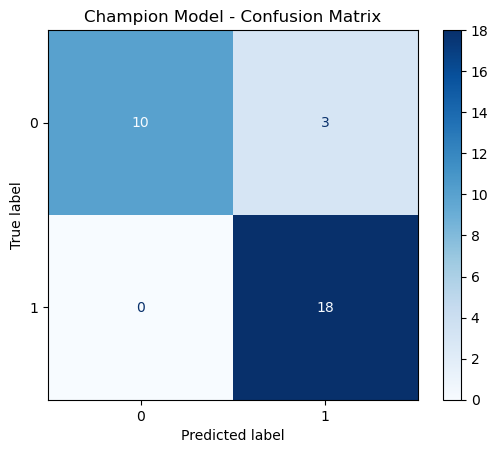

In [16]:
model.eval().to(device)



with torch.no_grad():
    logits = model(x_test.to(device))
    probs = torch.sigmoid(logits).cpu().numpy().ravel()

y_true = y_test.cpu().numpy().ravel()

# Metrics
test_auc_dense = roc_auc_score(y_true, probs)
preds = (probs >= 0.5).astype(int)

accuracy_dense = accuracy_score(y_true, preds)
precision_dense = precision_score(y_true, preds, zero_division=0)
recall_dense = recall_score(y_true, preds, zero_division=0)

print("\nTEST EVALUATION DENSE MODEL (Champion Model)")
print(f"AUC: {test_auc_dense:.4f}")
print(f"Accuracy: {accuracy_dense:.4f}")
print(f"Precision: {precision_dense:.4f}")
print(f"Recall: {recall_dense:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Champion Model - Confusion Matrix")
plt.show()

# **CNN model**

## Define functions needed

In [17]:
def init_weights(m):
    if isinstance(m, nn.Linear):
        nn.init.kaiming_uniform_(m.weight)
        nn.init.zeros_(m.bias)

class SquatClassifierCNN(nn.Module):
    def __init__(self, input_dim, dropout_rate=0.25):
        super().__init__()
        self.input_dim = input_dim
        self.dropout_rate = dropout_rate
        self.conv_block1 = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=3, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        self.conv_block2 = nn.Sequential(
            nn.Conv2d(32, 16, kernel_size=3, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
        )
        self.conv_block3 = nn.Sequential(
            nn.Conv2d(16, 8, kernel_size=3, padding=2),
            nn.BatchNorm2d(8),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),
            nn.Dropout2d(dropout_rate)
        )
        self._flat_size = self._get_flat_size()
        self.classifier = nn.Sequential(
            nn.Linear(self._flat_size, 32),
            nn.ReLU(),
            nn.Dropout(dropout_rate),
            nn.Linear(32, 1)
        )
        self.classifier.apply(init_weights)

    def _get_flat_size(self):
        with torch.no_grad():
            dummy = torch.zeros(1, 1, self.input_dim[0], self.input_dim[1])
            x = self.conv_block1(dummy)
            x = self.conv_block2(x)
            x = self.conv_block3(x)
        return x.view(1, -1).shape[1]

    def forward(self, x):
        x = self.conv_block1(x)
        x = self.conv_block2(x)
        x = self.conv_block3(x)
        x = x.view(x.size(0), -1)
        return self.classifier(x)

def build_cnn_model(config, input_dim):
    return SquatClassifierCNN(input_dim=input_dim, dropout_rate=config["dropout"]).to(device)

## Load trained CNN champion model

In [18]:
# Load weights and hyperparameters
model_path = "champion_CNN.pt"
info_path = "champion_CNN.json"

state_dict = torch.load(model_path, map_location=device)

with open(info_path, "r") as f:
    champion_info = json.load(f)

best_config = champion_info["hyperparameters"]



# Rebuild model
final_model = build_cnn_model(best_config, input_shape)
final_model.load_state_dict(state_dict)
final_model.to(device)

# Summarize model
model_summary = summary(final_model, input_size=(1, 1, input_shape[0], input_shape[1]))

print("CNN")
print(model_summary)

CNN
Layer (type:depth-idx)                   Output Shape              Param #
SquatClassifierCNN                       [1, 1]                    --
├─Sequential: 1-1                        [1, 32, 29, 12]           --
│    └─Conv2d: 2-1                       [1, 32, 60, 26]           320
│    └─ReLU: 2-2                         [1, 32, 60, 26]           --
│    └─MaxPool2d: 2-3                    [1, 32, 29, 12]           --
│    └─Dropout2d: 2-4                    [1, 32, 29, 12]           --
├─Sequential: 1-2                        [1, 16, 15, 7]            --
│    └─Conv2d: 2-5                       [1, 16, 31, 14]           4,624
│    └─ReLU: 2-6                         [1, 16, 31, 14]           --
│    └─MaxPool2d: 2-7                    [1, 16, 15, 7]            --
├─Sequential: 1-3                        [1, 8, 8, 4]              --
│    └─Conv2d: 2-8                       [1, 8, 17, 9]             1,160
│    └─BatchNorm2d: 2-9                  [1, 8, 17, 9]             16
│   


TEST EVALUATION CNN MODEL (Champion Model)
AUC: 0.9701
Accuracy: 0.9677
Precision: 1.0000
Recall: 0.9444


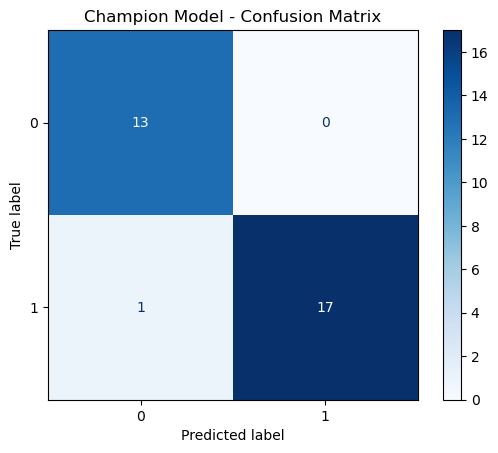

In [19]:
final_model.eval().to(device)
with torch.no_grad():
    logits = final_model(x_test_cnn.to(device))
    probs = torch.sigmoid(logits).cpu().numpy().ravel()

y_true = y_test.cpu().numpy().ravel()

# Metrics
test_auc = roc_auc_score(y_true, probs)
preds = (probs >= 0.5).astype(int)

accuracy = accuracy_score(y_true, preds)
precision = precision_score(y_true, preds, zero_division=0)
recall = recall_score(y_true, preds, zero_division=0)

print("\nTEST EVALUATION CNN MODEL (Champion Model)")
print(f"AUC: {test_auc:.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")

# Confusion matrix
cm = confusion_matrix(y_true, preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(cmap="Blues")
plt.title("Champion Model - Confusion Matrix")
plt.show()

# **Model comparison: Dense vs CNN**

In [37]:
param_quotient = round(14377 / 92033, 3)

df = pd.DataFrame({
    "Model": ["Dense Model", "CNN Model"],
    "Test AUC": [round(test_auc_dense, 4), round(test_auc, 4)],
    "Test Accuracy": [round(accuracy_dense, 4), round(accuracy, 4)],
    "Test Precision": [round(precision_dense, 4), round(precision, 4)],
    "Test Recall": [round(recall_dense, 4), round(recall, 4)],
    "# Parameters": [92033, 14377]
})

display(df.style.set_table_attributes("style='font-size:16px'"))

print(f"\n Parameter quotient (# CNN model params / # Dense model params): {param_quotient * 100}%")



,Model,Test AUC,Test Accuracy,Test Precision,Test Recall,# Parameters
0,Dense Model,0.914500,0.903200,0.857100,1.000000,92033
1,CNN Model,0.970100,0.967700,1.000000,0.944400,14377



 Parameter quotient (# CNN model params / # Dense model params): 15.6%


# **Future works**

- Augment data to get even more training samples, we didn't due to our saftisfication about the metrics.
- See the effects of the CNN squat classifier on a video we filmed ourselves